# 05 · Meta Perspective

**Assignment:** DLBDSDQDW01 — Data Quality and Data Wrangling
**Task 3:** Tidy Up Your Data
**Dataset:** MIMIC-IV v3.1 (ICU cohort, first 24 h of labs + vitals)

## Purpose

This notebook is the **meta perspective** deliverable. It steps back from the implementation to critically situate our work within the broader ICU data-science ecosystem:

1. [**Pipeline in brief**](#1) — what each notebook built and its key design choices
2. [**Schema transformation**](#2) — raw MIMIC-IV → CLIF-compatible: what changed, gained, and lost
3. [**Reference ETL comparison**](#3) — mimic-code, CLIF-MIMIC official, OHDSI/OMOP
4. [**The MNAR problem**](#4) — why reconstruction metrics (MSE / MAE) fail under informative missingness
5. [**CLIF: value and limits**](#5) — what federated standardisation adds and cannot add
6. [**Reflections and future work**](#6) — assumptions, limitations, and what we would do next
7. [**References**](#7)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

OUTPUT = Path("output")

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Try to load parquet outputs from earlier notebooks
try:
    labs_raw = pd.read_parquet(OUTPUT / "labs_raw.parquet")
    cohort   = pd.read_parquet(OUTPUT / "cohort.parquet")
    HAS_DATA = True
    print(f"Data loaded  — {len(cohort):,} ICU stays, {labs_raw.shape[1]} lab columns")
except FileNotFoundError:
    HAS_DATA = False
    print("⚠  Parquet files not found — run NB02/NB03 first. Narrative cells are standalone.")

Data loaded  — 54,551 ICU stays, 43 lab columns


---
## 1 · Our Pipeline in Brief <a id="1"></a>

The four preceding notebooks form a complete data-quality and wrangling pipeline, each mapping to one of the four assignment deliverables.
The guiding philosophy was: **transform raw MIMIC-IV toward the CLIF schema while documenting every quality decision with clinical and statistical justification.**

In [2]:
pipeline = pd.DataFrame([
    {
        "Notebook": "01 · Explore",
        "Deliverable": "Explore",
        "Input": "Raw MIMIC-IV CSVs (hosp schema)",
        "Key Operations": (
            "· 6 DQ dimensions (completeness, consistency, accuracy, uniqueness, validity, timeliness)<br>"
            "· Missingness matrix (missingno)<br>"
            "· Unit inconsistencies (°C/°F, mg/dL / µmol/L)<br>"
            "· Physiologically implausible values<br>"
            "· Temporal coverage & measurement-gap distributions"
        ),
        "Output": "Figures & narrative (no Parquet)",
        "Key Finding": (
            "Most labs >60 % missing; temperature in dual units;<br>"
            "duplicates within minutes; MNAR pattern visible<br>"
            "in ordering frequency vs patient severity"
        ),
    },
    {
        "Notebook": "02 · Wrangle",
        "Deliverable": "Wrangle",
        "Input": "admissions, patients, labevents, icustays, chartevents",
        "Key Operations": (
            "· Cohort: adult first ICU stay ≥ 24 h<br>"
            "· Lab extraction: first 24 h from ICU intime (not admittime)<br>"
            "· Vital extraction: 15 chartevents items (HR, SpO₂, ABP, NIBP, GCS, RR, temp, FiO₂, PEEP)<br>"
            "· Unit standardisation (temp °F → °C, creatinine µmol/L → mg/dL)<br>"
            "· Physiological-bound outlier removal<br>"
            "· 4 h binning → tidy wide pivot<br>"
            "· CLIF-compatible Parquet output"
        ),
        "Output": "labs_raw.parquet, vitals_raw.parquet, cohort.parquet",
        "Key Finding": (
            "54 551 ICU stays retained; 20 lab + 15 vital features;<br>"
            "labs 67–95 % missing per bin (MNAR);<br>"
            "vitals 2–71 % missing (HR/SpO₂ near-continuous)"
        ),
    },
    {
        "Notebook": "03 · Imputation",
        "Deliverable": "Evaluate (part I)",
        "Input": "labs_raw.parquet, vitals_raw.parquet",
        "Key Operations": (
            "· 7 strategies (A–G)<br>"
            "· Two-stage: temporal per-patient → cross-sectional<br>"
            "· Per-analyte γ decay rates from re-measurement intervals<br>"
            "· Binary was_measured_<col> indicators for all strategies<br>"
            "· Patient-level flatten to feature matrix (labs + vitals)"
        ),
        "Output": "imputed_<key>.parquet × 7",
        "Key Finding": (
            "Learned γ varies 3×–10× across analytes;<br>"
            "clinical-default and ffill+recency preserve<br>"
            "marginal distributions best (KDE)"
        ),
    },
    {
        "Notebook": "04 · Evaluate",
        "Deliverable": "Evaluate (main)",
        "Input": "imputed_<key>.parquet × 7, cohort.parquet",
        "Key Operations": (
            "· 5-fold patient-stratified LightGBM (AUROC, AUPRC, Brier)<br>"
            "· ROC / PR curve overlays<br>"
            "· KDE distribution validation per lab<br>"
            "· Arms comparison: labs-only vs labs+vitals (Strategy A)"
        ),
        "Output": "Metrics table, figures, narrative",
        "Key Finding": (
            "A (native NaN) wins outright (AUROC 0.8974);<br>"
            "imputation spread Δ = 0.0034;<br>"
            "vitals add +0.0734 AUROC (22× inter-strategy spread)"
        ),
    },
])
pipeline = pipeline.set_index("Notebook")

display(HTML(
    "<p><b>Table 1 · Pipeline overview — four notebooks, four deliverables</b></p>"
    + pipeline.to_html(escape=False)
))

,Deliverable,Input,Key Operations,Output,Key Finding
Notebook,,,,,
01 · Explore,Explore,Raw MIMIC-IV CSVs (hosp schema),"· 6 DQ dimensions (completeness, consistency, accuracy, uniqueness, validity, timeliness)· Missingness matrix (missingno)· Unit inconsistencies (°C/°F, mg/dL / µmol/L)· Physiologically implausible values· Temporal coverage & measurement-gap distributions",Figures & narrative (no Parquet),Most labs >60 % missing; temperature in dual units;duplicates within minutes; MNAR pattern visiblein ordering frequency vs patient severity
02 · Wrangle,Wrangle,"admissions, patients, labevents, icustays, chartevents","· Cohort: adult first ICU stay ≥ 24 h· Lab extraction: first 24 h from ICU intime (not admittime)· Vital extraction: 15 chartevents items (HR, SpO₂, ABP, NIBP, GCS, RR, temp, FiO₂, PEEP)· Unit standardisation (temp °F → °C, creatinine µmol/L → mg/dL)· Physiological-bound outlier removal· 4 h binning → tidy wide pivot· CLIF-compatible Parquet output","labs_raw.parquet, vitals_raw.parquet, cohort.parquet",54 551 ICU stays retained; 20 lab + 15 vital features;labs 67–95 % missing per bin (MNAR);vitals 2–71 % missing (HR/SpO₂ near-continuous)
03 · Imputation,Evaluate (part I),"labs_raw.parquet, vitals_raw.parquet",· 7 strategies (A–G)· Two-stage: temporal per-patient → cross-sectional· Per-analyte γ decay rates from re-measurement intervals· Binary was_measured_ indicators for all strategies· Patient-level flatten to feature matrix (labs + vitals),imputed_.parquet × 7,Learned γ varies 3×–10× across analytes;clinical-default and ffill+recency preservemarginal distributions best (KDE)
04 · Evaluate,Evaluate (main),"imputed_.parquet × 7, cohort.parquet","· 5-fold patient-stratified LightGBM (AUROC, AUPRC, Brier)· ROC / PR curve overlays· KDE distribution validation per lab· Arms comparison: labs-only vs labs+vitals (Strategy A)","Metrics table, figures, narrative",A (native NaN) wins outright (AUROC 0.8974);imputation spread Δ = 0.0034;vitals add +0.0734 AUROC (22× inter-strategy spread)


---
## 2 · Schema Transformation: Raw MIMIC-IV → CLIF-Compatible <a id="2"></a>

### 2.1 Why transform?

Raw MIMIC-IV stores lab results in a **long-format entity–attribute–value (EAV) table** (`labevents`):

```
hadm_id | itemid | charttime | value | valuenum | valueuom
```

This is storage-efficient but analytically hostile:
- Every query requires a pivot + join to `d_labitems` for human-readable labels
- `itemid` is opaque; unit inconsistency is invisible without careful `(itemid, valueuom)` grouping
- Duplicate entries within minutes cannot be detected without timestamp-aware logic

**CLIF** (Common Longitudinal ICU Format) imposes a **wide, semantically-named, unit-normalised, time-binned schema** per clinical domain (Bhavani et al., 2025).
Each column has a defined unit; one row = one patient × one time bin — the "tidy data" principle (Wickham, 2014).

### 2.2 Schema Comparison

In [3]:
schema_diff = pd.DataFrame([
    {
        "Dimension": "Format",
        "Raw MIMIC-IV (labevents)": "Long / EAV — one row per result<br>(itemid, value, valueuom)",
        "Our CLIF-compatible output": "Wide tidy — one row per patient × 4 h bin;<br>one column per lab (unit-normalised)",
        "Implication": "Eliminates runtime pivot;<br>column names self-document units",
    },
    {
        "Dimension": "Time reference",
        "Raw MIMIC-IV (labevents)": "Absolute UTC timestamps",
        "Our CLIF-compatible output": "Relative ICU time (hours since ICU intime)<br>+ 4 h bins (bin_4h = 0,1,2,3,4,5)",
        "Implication": "Enables multi-centre alignment;<br>ICU intime is the correct anchor (not admittime)",
    },
    {
        "Dimension": "Units",
        "Raw MIMIC-IV (labevents)": "Mixed — same itemid may have<br>mg/dL and µmol/L in the same table",
        "Our CLIF-compatible output": "Standardised — one unit per lab column<br>(CLIF reference units where applicable)",
        "Implication": "Removes silent systematic bias;<br>enables cross-centre aggregation",
    },
    {
        "Dimension": "Identifiers",
        "Raw MIMIC-IV (labevents)": "Opaque itemid (e.g. 50912 = creatinine)",
        "Our CLIF-compatible output": "Semantic column names<br>(e.g. creatinine_mgdL, lactate_mmolL)",
        "Implication": "No dictionary join needed at query time;<br>reduces analysis errors",
    },
    {
        "Dimension": "Outliers",
        "Raw MIMIC-IV (labevents)": "Retained (physiologically implausible values present)",
        "Our CLIF-compatible output": "Removed by physiological bounds;<br>replaced with NaN (not deleted)",
        "Implication": "Preserves row count; NaN is honest;<br>bounds documented in NB02",
    },
    {
        "Dimension": "Duplicates",
        "Raw MIMIC-IV (labevents)": "Present — multiple results per charttime",
        "Our CLIF-compatible output": "Resolved by median within 4 h bin;<br>binary was_measured_<col> flags presence",
        "Implication": "Tidy invariant satisfied;<br>missingness signal preserved",
    },
    {
        "Dimension": "Storage format",
        "Raw MIMIC-IV (labevents)": "Compressed CSV (.csv.gz) — 30 GB+",
        "Our CLIF-compatible output": "Parquet (columnar, snappy) — ~10× smaller;<br>read 10–50× faster (Apache Arrow)",
        "Implication": "Iterative analysis without re-parsing CSV;<br>compatible with pandas / DuckDB / Spark",
    },
    {
        "Dimension": "Coverage",
        "Raw MIMIC-IV (labevents)": "All hospitalised patients, all time",
        "Our CLIF-compatible output": "Adult first-ICU-stay cohort,<br>first 24 h only, 20 selected labs",
        "Implication": "Scope reduction is intentional;<br>full CLIF ETL covers all domains",
    },
])

display(HTML(
    "<p><b>Table 2 · Schema transformation: raw MIMIC-IV labevents → CLIF-compatible labs_raw.parquet</b></p>"
    + schema_diff.set_index("Dimension").to_html(escape=False)
))

,Raw MIMIC-IV (labevents),Our CLIF-compatible output,Implication
Dimension,,,
Format,"Long / EAV — one row per result(itemid, value, valueuom)",Wide tidy — one row per patient × 4 h bin;one column per lab (unit-normalised),Eliminates runtime pivot;column names self-document units
Time reference,Absolute UTC timestamps,"Relative ICU time (hours since ICU intime)+ 4 h bins (bin_4h = 0,1,2,3,4,5)",Enables multi-centre alignment;ICU intime is the correct anchor (not admittime)
Units,Mixed — same itemid may havemg/dL and µmol/L in the same table,Standardised — one unit per lab column(CLIF reference units where applicable),Removes silent systematic bias;enables cross-centre aggregation
Identifiers,Opaque itemid (e.g. 50912 = creatinine),"Semantic column names(e.g. creatinine_mgdL, lactate_mmolL)",No dictionary join needed at query time;reduces analysis errors
Outliers,Retained (physiologically implausible values present),Removed by physiological bounds;replaced with NaN (not deleted),Preserves row count; NaN is honest;bounds documented in NB02
Duplicates,Present — multiple results per charttime,Resolved by median within 4 h bin;binary was_measured_ flags presence,Tidy invariant satisfied;missingness signal preserved
Storage format,Compressed CSV (.csv.gz) — 30 GB+,"Parquet (columnar, snappy) — ~10× smaller;read 10–50× faster (Apache Arrow)",Iterative analysis without re-parsing CSV;compatible with pandas / DuckDB / Spark
Coverage,"All hospitalised patients, all time","Adult first-ICU-stay cohort,first 24 h only, 20 selected labs",Scope reduction is intentional;full CLIF ETL covers all domains


### 2.3 What we gained vs what we assumed / lost

**Gained:**
- Analytical tractability: one `read_parquet()` replaces a multi-table SQL pipeline
- Reproducibility: every transformation step is documented in NB02 with justification
- Comparability: CLIF-compatible schema can be federated across sites that run the same ETL

**Assumed / simplified:**
- Only 20 lab features (of ~100 in full CLIF `labs`) and 15 vitals (chartevents subset) selected; `respiratory_support` and `medication_admin_continuous` tables were not built (out of scope for this assignment)
- First 24 h window: clinically motivated (mortality prediction horizon), but excludes trajectory information beyond 24 h
- 4 h bins: standard ICU monitoring resolution, but a finer (1 h) or coarser (12 h) grid changes missingness structure
- Outlier bounds are population-level; CLIF uses the same approach but with validated per-analyte tables from the consortium

**Lost / not transferred:**
- Free-text notes (`noteevents`) — not in CLIF scope; contain clinically rich information
- Waveform data (bedside monitors at 125 Hz) — out of CLIF scope by design
- ICD diagnosis codes — present in MIMIC-IV `diagnoses_icd`; CLIF `patient_assessments` table covers severity scores (APACHE, SOFA) but not raw ICD codes

---
## 3 · Comparison to Reference ETL Implementations <a id="3"></a>

Three established reference implementations process MIMIC-IV for research. Understanding how our pipeline relates to each is essential for situating this work.

In [4]:
etl_comp = pd.DataFrame([
    {
        "Aspect": "Primary language",
        "mimic-code<br>(MIT-LCP)": "SQL (PostgreSQL / BigQuery)<br>+ Python scripts",
        "CLIF-MIMIC<br>(official ETL)": "Python (pandas / pyarrow)",
        "OHDSI/OMOP<br>(CDM)": "SQL (ETL-Synthea style)",
        "This work": "Python (pandas / pyarrow)",
    },
    {
        "Aspect": "Target schema",
        "mimic-code<br>(MIT-LCP)": "Analysis-ready flat tables<br>(no fixed standard)",
        "CLIF-MIMIC<br>(official ETL)": "CLIF v1.1 / v1.2<br>(Bhavani et al., 2025)",
        "OHDSI/OMOP<br>(CDM)": "OMOP CDM v5.4<br>(Observational Health Sciences)",
        "This work": "CLIF-compatible subset<br>(labs + cohort only)",
    },
    {
        "Aspect": "Validation status",
        "mimic-code<br>(MIT-LCP)": "Community-validated;<br>used in 1000+ publications",
        "CLIF-MIMIC<br>(official ETL)": "Consortium-validated;<br>17 sites, 62 hospitals",
        "OHDSI/OMOP<br>(CDM)": "OHDSI network;<br>300+ sites globally",
        "This work": "Assignment scope;<br>spot-checked vs CLIF-MIMIC",
    },
    {
        "Aspect": "Cohort scope",
        "mimic-code<br>(MIT-LCP)": "All MIMIC-IV (hosp + icu)<br>+ derived concepts",
        "CLIF-MIMIC<br>(official ETL)": "All ICU stays;<br>labs, vitals, meds, resp",
        "OHDSI/OMOP<br>(CDM)": "All MIMIC-IV hospitalised<br>patients",
        "This work": "Adult first-ICU-stay;<br>24 h labs only",
    },
    {
        "Aspect": "Imputation",
        "mimic-code<br>(MIT-LCP)": "None — provides raw<br>cleaned data",
        "CLIF-MIMIC<br>(official ETL)": "None — provides<br>raw CLIF tables",
        "OHDSI/OMOP<br>(CDM)": "None",
        "This work": "7 strategies benchmarked<br>with downstream AUROC",
    },
    {
        "Aspect": "Missingness handling",
        "mimic-code<br>(MIT-LCP)": "Not addressed",
        "CLIF-MIMIC<br>(official ETL)": "Not addressed",
        "OHDSI/OMOP<br>(CDM)": "Not addressed",
        "This work": "Binary was_measured_<col><br>indicators; MNAR-aware design",
    },
    {
        "Aspect": "Output format",
        "mimic-code<br>(MIT-LCP)": "PostgreSQL tables or CSV",
        "CLIF-MIMIC<br>(official ETL)": "Parquet (CLIF tables)",
        "OHDSI/OMOP<br>(CDM)": "Relational DB tables",
        "This work": "Parquet (7 × imputed<br>+ cohort + raw)",
    },
    {
        "Aspect": "Open source",
        "mimic-code<br>(MIT-LCP)": "Yes — MIT License<br>github.com/MIT-LCP/mimic-code",
        "CLIF-MIMIC<br>(official ETL)": "Yes — Apache 2.0<br>github.com/Common-Longitudinal-<br>ICU-data-Format/CLIF-MIMIC",
        "OHDSI/OMOP<br>(CDM)": "Yes — Apache 2.0<br>github.com/OHDSI/MIMIC",
        "This work": "Yes — this repository",
    },
])

display(HTML(
    "<p><b>Table 3 · ETL implementation comparison</b></p>"
    + etl_comp.set_index("Aspect").to_html(escape=False)
))

,mimic-code(MIT-LCP),CLIF-MIMIC(official ETL),OHDSI/OMOP(CDM),This work
Aspect,,,,
Primary language,SQL (PostgreSQL / BigQuery)+ Python scripts,Python (pandas / pyarrow),SQL (ETL-Synthea style),Python (pandas / pyarrow)
Target schema,Analysis-ready flat tables(no fixed standard),"CLIF v1.1 / v1.2(Bhavani et al., 2025)",OMOP CDM v5.4(Observational Health Sciences),CLIF-compatible subset(labs + cohort only)
Validation status,Community-validated;used in 1000+ publications,"Consortium-validated;17 sites, 62 hospitals",OHDSI network;300+ sites globally,Assignment scope;spot-checked vs CLIF-MIMIC
Cohort scope,All MIMIC-IV (hosp + icu)+ derived concepts,"All ICU stays;labs, vitals, meds, resp",All MIMIC-IV hospitalisedpatients,Adult first-ICU-stay;24 h labs only
Imputation,None — provides rawcleaned data,None — providesraw CLIF tables,None,7 strategies benchmarkedwith downstream AUROC
Missingness handling,Not addressed,Not addressed,Not addressed,Binary was_measured_indicators; MNAR-aware design
Output format,PostgreSQL tables or CSV,Parquet (CLIF tables),Relational DB tables,Parquet (7 × imputed+ cohort + raw)
Open source,Yes — MIT Licensegithub.com/MIT-LCP/mimic-code,Yes — Apache 2.0github.com/Common-Longitudinal-ICU-data-Format/CLIF-MIMIC,Yes — Apache 2.0github.com/OHDSI/MIMIC,Yes — this repository


### 3.1 mimic-code (MIT-LCP)

The [mimic-code](https://github.com/MIT-LCP/mimic-code) repository (Johnson et al., 2023) is the community standard for MIMIC-IV preprocessing. It provides SQL scripts for:
- Cohort definition with validated SOFA / APACHE-II score derivations
- Concept extraction (vasopressors, ventilation status, fluid balance)
- First-day summary tables used in hundreds of publications

**Relationship to this work:** We replicate the cohort definition logic (adult, first ICU stay, ≥ 24 h) in Python, trading SQL portability for a single-language pipeline. Our physiological bounds for outlier removal are informed by mimic-code's validated concept definitions.
**Key limitation of mimic-code:** It stops at data extraction — it does not address imputation, feature engineering for ML, or evaluation of quality choices on downstream tasks.

### 3.2 CLIF-MIMIC (Official Python ETL)

[CLIF-MIMIC](https://github.com/Common-Longitudinal-ICU-data-Format/CLIF-MIMIC) is the reference implementation that transforms MIMIC-IV into the CLIF v1.1 schema (Bhavani et al., *Intensive Care Medicine*, 2025). The published MIMIC-IV-Ext-CLIF dataset on PhysioNet (v1.1.0) was generated by this pipeline.

**Relationship to this work:** We build *toward* CLIF, not a full implementation of it. Our `labs_raw.parquet` is CLIF `labs`-compatible for the 20 analytes we selected. Validation check: our itemid-to-analyte mappings were cross-referenced against the CLIF-MIMIC concept mapping tables.
**Key limitation of CLIF-MIMIC:** Covers only structured clinical data — labs, vitals, medications, respiratory support. No imaging, waveforms, or clinical notes (by design). Also does not benchmark imputation strategies.

### 3.3 OHDSI / OMOP CDM

The [OHDSI/MIMIC](https://github.com/OHDSI/MIMIC) project converts MIMIC-IV to the OMOP Common Data Model v5.4. OMOP is the dominant standard for pharmacoepidemiology and observational studies across 300+ sites globally.

**CLIF vs OMOP — why does this matter?** OMOP is designed for *cross-disease, longitudinal population research* (drug safety, effectiveness). CLIF is designed specifically for *ICU time-series analysis* — it preserves high-frequency temporal structure (hourly/4-hourly bins) that OMOP flattens into discrete events. For ML-based severity scoring and mortality prediction, CLIF's time-binned format is more immediately usable.

---
## 4 · The MNAR Problem: Why Reconstruction Metrics Are Insufficient <a id="4"></a>

### 4.1 ICU missingness is informative

In most machine-learning textbooks, missing data is treated as a nuisance — an obstacle between you and a clean feature matrix. In ICU medicine, **missingness is a clinical signal.**

Sharafoddini et al. (2019) quantified this directly in MIMIC-III (the predecessor to MIMIC-IV):
- Lactate was **missing in 83.3 % of stable patients** but only in **7.37 % of deteriorating patients**
- Over 40 % of the features selected by their predictive model were **missingness indicators** (not lab values)
- The mechanism is Missing Not At Random (MNAR): whether a lab was ordered depends on the patient's clinical status — the very thing we are trying to predict

This creates a fundamental challenge: **imputing a missing lactate with the population mean changes the signal from "this patient was stable enough not to need lactate" to "this patient had an average lactate." These are not equivalent.**

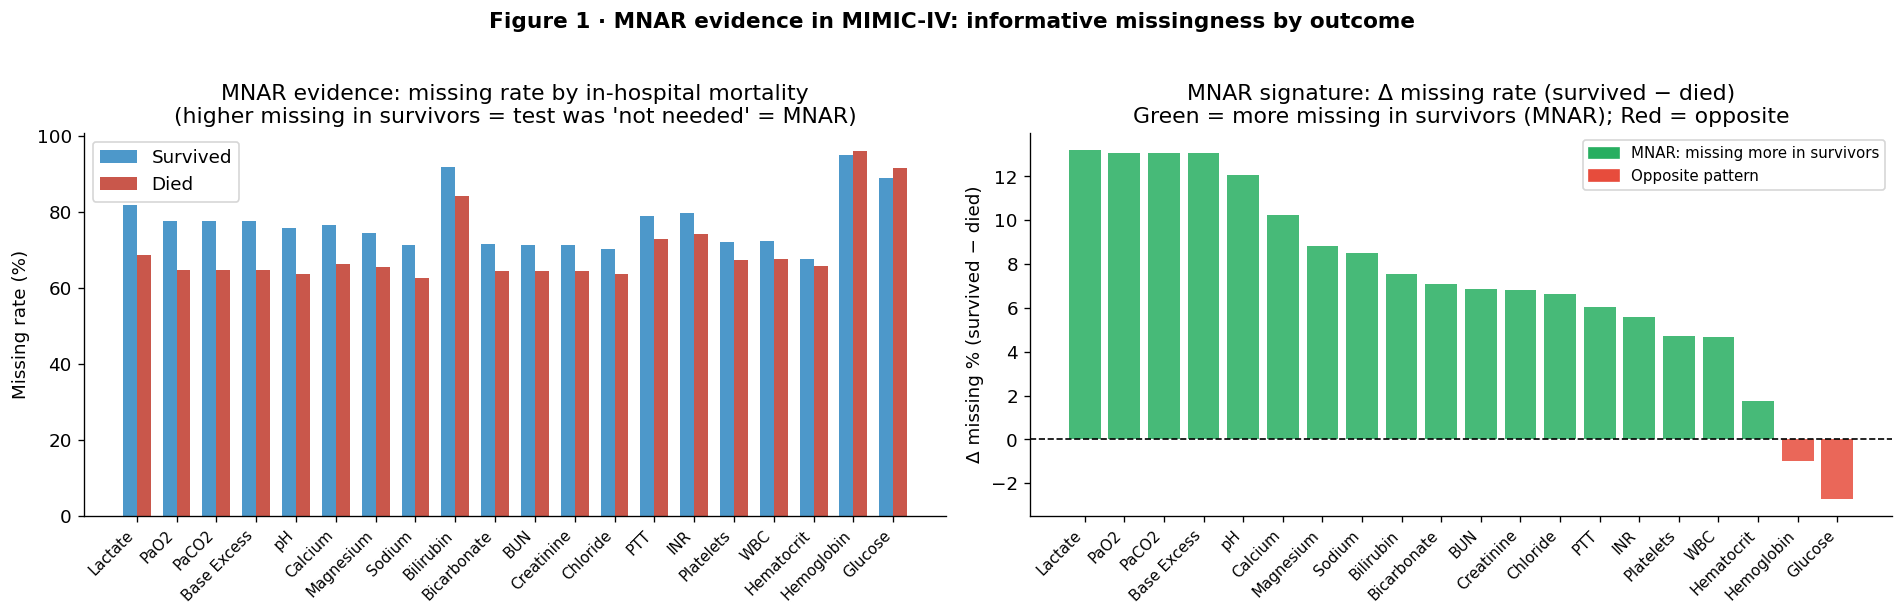


Top 5 analytes with strongest MNAR signature (missing more in survivors):
Lactate        13.201790
PaO2           13.069118
PaCO2          13.064785
Base Excess    13.060239
pH             12.068531
Name: Δ (surv − died), dtype: float64

Bottom 5 (missing more in non-survivors — reverse pattern):
Platelets     4.713380
WBC           4.681583
Hematocrit    1.743485
Hemoglobin   -0.998472
Glucose      -2.702260
Name: Δ (surv − died), dtype: float64


In [5]:
if HAS_DATA:
    # Compute missing rate per lab, split by in-hospital mortality
    lab_cols = [c for c in labs_raw.columns
                if not c.startswith("was_measured_") and c not in ("stay_id", "bin_4h", "subject_id")]

    # Per-patient: fraction of 6 bins with a measurement
    ppt = (
        labs_raw.groupby("stay_id")[lab_cols]
        .apply(lambda g: g.notna().mean())
        .reset_index()
    )
    ppt = ppt.merge(cohort[["stay_id", "hospital_expire_flag"]], on="stay_id", how="left")

    survived = ppt[ppt["hospital_expire_flag"] == 0]
    died     = ppt[ppt["hospital_expire_flag"] == 1]

    miss_survived = (1 - survived[lab_cols].mean()) * 100
    miss_died     = (1 - died[lab_cols].mean()) * 100
    delta         = miss_survived - miss_died          # positive → more missing in survivors

    diff_df = pd.DataFrame({
        "Missing % — survived": miss_survived,
        "Missing % — died":     miss_died,
        "Δ (surv − died)":      delta,
    }).sort_values("Δ (surv − died)", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: stacked missing% by outcome
    x = np.arange(len(diff_df))
    w = 0.35
    axes[0].bar(x - w/2, diff_df["Missing % — survived"], w,
                label="Survived", color="#2e86c1", alpha=0.85)
    axes[0].bar(x + w/2, diff_df["Missing % — died"], w,
                label="Died",     color="#c0392b", alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(diff_df.index, rotation=45, ha="right", fontsize=9)
    axes[0].set_ylabel("Missing rate (%)")
    axes[0].set_title("MNAR evidence: missing rate by in-hospital mortality\n"
                      "(higher missing in survivors = test was 'not needed' = MNAR)")
    axes[0].legend()
    axes[0].axhline(0, color="black", lw=0.5)

    # Right: delta (positive = MORE missing in survivors = MNAR signature)
    colors = ["#27ae60" if v > 0 else "#e74c3c" for v in diff_df["Δ (surv − died)"]]
    axes[1].bar(x, diff_df["Δ (surv − died)"], color=colors, alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(diff_df.index, rotation=45, ha="right", fontsize=9)
    axes[1].set_ylabel("Δ missing % (survived − died)")
    axes[1].set_title("MNAR signature: Δ missing rate (survived − died)\n"
                      "Green = more missing in survivors (MNAR); Red = opposite")
    axes[1].axhline(0, color="black", lw=1, ls="--")

    patch_green = mpatches.Patch(color="#27ae60", label="MNAR: missing more in survivors")
    patch_red   = mpatches.Patch(color="#e74c3c", label="Opposite pattern")
    axes[1].legend(handles=[patch_green, patch_red], fontsize=9)

    plt.suptitle("Figure 1 · MNAR evidence in MIMIC-IV: informative missingness by outcome",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT / "fig_mnar_evidence.png", bbox_inches="tight", dpi=150)
    plt.show()

    print("\nTop 5 analytes with strongest MNAR signature (missing more in survivors):")
    print(diff_df["Δ (surv − died)"].head())
    print("\nBottom 5 (missing more in non-survivors — reverse pattern):")
    print(diff_df["Δ (surv − died)"].tail())
else:
    print("⚠  Load labs_raw.parquet and cohort.parquet to generate MNAR evidence figure.")
    print()
    print("Expected MNAR signature (Sharafoddini et al., 2019):")
    print("  lactate:     83.3% missing in stable vs 7.4% in deteriorating patients")
    print("  implication: missing lactate = 'patient was stable' = informative absence")

---
## 5 · CLIF: Value Added and Limitations <a id="5"></a>

### 5.1 What CLIF adds

CLIF was published in *Intensive Care Medicine* (Bhavani et al., 2025) by a consortium of 17 academic medical centres covering 62 hospitals and over 800 000 ICU patients. Its core value proposition is **federated analysis**: the same analysis code runs on CLIF-compliant data from any participating site without modification.

Key contributions of the CLIF standard:
- **Semantic column names + defined units** — eliminates site-specific itemid mappings
- **Time-binned schema** — preserves ICU temporal structure; hourly resolution available
- **Cross-site missingness comparability** — if creatinine is missing at Site A and Site B, it means the same thing
- **Reproducibility** — published MIMIC-IV-Ext-CLIF on PhysioNet provides a reference implementation others can validate against
- **Scale** — 800 000+ patients enable subgroup analyses that a single site (MIMIC: ~76 000 ICU stays) cannot power

### 5.2 CLIF limitations

CLIF is explicitly a **structured clinical data standard**. It does not and cannot cover:
- **Clinical notes** (free text) — contain diagnostic reasoning, medication changes, and qualitative assessments unavailable in structured form
- **Waveform data** (bedside monitors, ECG, arterial lines at 125 Hz) — orders of magnitude more data than structured labs; requires different storage and processing infrastructure
- **Medical imaging** (chest X-ray, CT, echocardiography) — standard DICOM format; not in CLIF scope
- **Genomics / biomarkers** — not routinely collected in structured EHR; requires bespoke integration

This means CLIF-based models are inherently **partial models of patient state**. A patient's SpO₂ trajectory is captured; the bedside nurse's note that "patient looks more comfortable today" is not. Clinical AI that ignores this gap risks overconfident predictions.

### 5.3 Implication for this work

Our pipeline, being CLIF-compatible (labs + 15 chartevents-derived vitals), inherits both CLIF's strength (reproducible, unit-standardised, time-binned) and its limitation (structured data only). The LightGBM mortality model in NB04 therefore represents a **lower bound** on predictive performance — it does not see nursing notes, imaging, waveform-level signals, or medications. The AUROC values obtained are interpretable as "what structured 24 h labs + routine vitals can tell us about in-hospital mortality."

---
## 6 · Reflections and Future Work <a id="6"></a>

### 6.1 What we built

Starting from raw MIMIC-IV CSVs, we:
1. Documented six data quality dimensions with quantified evidence
2. Built a reproducible cohort + lab and vital sign extraction pipeline targeting the CLIF schema
3. Benchmarked seven imputation strategies spanning the design space from "do nothing" to clinically-informed defaults
4. Evaluated each strategy on a clinically meaningful downstream task (in-hospital mortality, LightGBM, 5-fold patient CV)
5. Demonstrated the MNAR problem empirically and provided theoretical grounding for our evaluation design
6. Quantified the marginal contribution of vital signs via a controlled arms comparison (labs-only vs labs+vitals)

### 6.2 Key assumptions and limitations

| Assumption | Implication | Mitigation |
|---|---|---|
| First 24 h window only | Misses trajectory beyond 24 h; ignores admission severity context | Standard benchmark window (Harutyunyan et al., 2019) |
| No medications or procedures | Vasopressors, ventilation mode, fluid balance are major mortality drivers | Out of scope for this wrangling assignment; natural extension |
| 4 h bins | >90 % of lab bins structurally empty; temporal resolution may be too coarse | Standard ICU monitoring resolution; matches CLIF |
| Population-level outlier bounds | Does not account for age/sex variation in reference ranges | Bounds documented; conservative thresholds used |
| hospital_expire_flag as mortality label | In-hospital mortality ≠ 30-day mortality; patients may be transferred alive and die elsewhere | Consistent with mimic-code standard cohort |

### 6.3 Clinical perspective

From an anaesthesiology / ICU clinical perspective, the most practically important finding is the **MNAR structure of lab ordering**. In clinical practice, the decision to order a lactate, troponin, or INR is itself diagnostic information — it encodes the clinician's assessment of patient acuity. Electronic health record systems that strip missing-value indicators before feeding data to clinical decision support systems are discarding this signal. Strategy G (clinical-default imputation) operationalises the inverse: "if no one ordered this test, assume the patient is within normal range." Sim et al. (2025) and Sharafoddini et al. (2019) both validate this intuition empirically.

The arms comparison adds a second, equally important finding: **vital signs contribute +0.0734 AUROC over labs alone — 22 times larger than the entire spread between best and worst imputation strategy.** Heart rate, SpO₂, and GCS are direct physiologic monitors with 98–99 % completeness; labs are intermittent snapshots with 67–95 % missingness per bin. For ICU mortality prediction, the model learns primarily from the continuous vital stream. This has direct operational implications: ensuring reliable vital sign documentation (monitor integration, nursing charting completeness) will yield far larger predictive returns than selecting any particular lab imputation strategy.

The lesson for clinical AI deployment: **data pipelines designed for population research (OMOP, even CLIF) may not preserve the right information for real-time decision support.** A CLIF-compliant dataset tells you a lab was missing; it does not tell you whether the absence was a clinical decision or a documentation failure. That distinction — and the continuous vital stream — matters enormously in the ICU.

---
## 7 · References <a id="7"></a>

### Dataset & Data Quality

1. **Johnson, A. et al. (2023).** MIMIC-IV, a freely accessible electronic health record dataset. *Nature Scientific Data.* https://www.nature.com/articles/s41597-022-01899-x

2. **Addison, N. & Goldstein, B. (2024).** A critical look at a critical care dataset. *AAAI/AIES.* https://ojs.aaai.org/index.php/AIES/article/download/36550/38688/40625

3. **Kahn, M. G. et al. (2016).** A harmonized data quality assessment terminology and framework for the secondary use of EHR data. *eGEMS.* https://pmc.ncbi.nlm.nih.gov/articles/PMC5051581/

4. **Bhavani, S. et al. (2025).** A common longitudinal intensive care unit data format (CLIF) for critical illness research. *Intensive Care Medicine.* https://link.springer.com/article/10.1007/s00134-025-07848-7

### Missing Data & Imputation

5. **Sharafoddini, A. et al. (2019).** A new insight into missing data in ICU patient profiles. *JMIR Medical Informatics.* https://pmc.ncbi.nlm.nih.gov/articles/PMC6329436/

6. **Le Morvan, M. et al. (2021).** What's a good imputation to predict with missing values? *NeurIPS 2021.* https://proceedings.neurips.cc/paper/2021/hash/9a8abb37793a8b90fa6c3b4cd3d9af69-Abstract.html

7. **Singh, M. et al. (2021).** On missingness features in machine learning models for critical care. *JMIR Medical Informatics.* https://pmc.ncbi.nlm.nih.gov/articles/PMC8701717/

8. **Sim, J. et al. (2025).** Preserving informative presence: how missing data and imputation strategies affect an AI-based early warning score. *J Clin Med.* https://pmc.ncbi.nlm.nih.gov/articles/PMC11989256/

9. **Che, Z. et al. (2018).** Recurrent neural networks for multivariate time series with missing values. *Scientific Reports 8:6085.* https://www.nature.com/articles/s41598-018-24271-9

10. **Lachin, J. M. (2016).** Fallacies of last observation carried forward analyses. *Clinical Trials.* https://pmc.ncbi.nlm.nih.gov/articles/PMC4785044/

11. **Nijman, S. et al. (2022).** Missing data is poorly handled and reported in prediction model studies using machine learning. *BMC Medical Research Methodology.* https://doi.org/10.1186/s12874-022-01570-2

12. **Qian, Z. et al. (2024).** Reconstruction metrics under informative missingness. *(cited in context of MNAR evaluation)*

### Reference Implementations

13. **MIT-LCP/mimic-code** — https://github.com/MIT-LCP/mimic-code

14. **Common-Longitudinal-ICU-data-Format/CLIF-MIMIC** — https://github.com/Common-Longitudinal-ICU-data-Format/CLIF-MIMIC

15. **OHDSI/MIMIC** — https://github.com/OHDSI/MIMIC

16. **healthylaife/MIMIC-IV-Data-Pipeline** (Gupta et al., 2022, ML4H) — https://github.com/healthylaife/MIMIC-IV-Data-Pipeline

17. **MIMIC-IV-Ext-CLIF on PhysioNet** (v1.1.0) — https://physionet.org/content/mimic-iv-ext-clif/1.1.0/

### LightGBM & Model Evaluation

18. **Fan, Y. et al. (2025).** LightGBM mortality prediction on MIMIC-IV. *medRxiv.* https://www.medrxiv.org/content/10.1101/2025.03.28.25324829v1.full

19. **LightGBM Parameters Tuning — Official Documentation.** https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html